IMPORT SECTION

In [4]:
import os
from utils.utils import process_data
import tensorflow_datasets as tfds
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
from PIL import Image
from IPython import display
import numpy as np

DOWNLOAD DROID DATA

In [ ]:
 # List of the dataset of OXE to download
dataset_list = ["droid"]
download_dir = f"./data/{dataset_list[0]}" # directory where to download the pytorch tensors needed for offline training
os.makedirs(download_dir, exist_ok=True)


# Load in streaming the dataset
ds = tfds.load(dataset_list[0], 
               data_dir="gs://gresearch/robotics", 
               split="train", 
               shuffle_files=False, 
               )

droid_lang_keys = ['language_instruction', 'language_instruction_2', 'language_instruction_3']

num_episodes_to_save = 5
saved_count = 0

pbar = tqdm(total=num_episodes_to_save, desc=f"Download {dataset_list[0]} episodes", unit="ep")

try:
    for i, episode in enumerate(ds):
        
        # Per ora metti un limite per testare (es. i primi 50 episodi)
        if saved_count >= num_episodes_to_save: 
            break
        
        #tqdm.write(f"--- Episode received from Cloud")
        video_pt, states_pt, action_pt, language_instructions = process_data(episode=episode, 
                                                                            num_frames=16, 
                                                                            fps=15, 
                                                                            window_second_size=4, 
                                                                            lang_keys=droid_lang_keys)
        if video_pt is not None:
            sample = {
                "video": video_pt,      # [16, 3, 256, 256]
                "states": states_pt,    # [16, 7]
                "actions": action_pt,   # [15, 7]
                "language": language_instructions
            }
            
            file_path = os.path.join(download_dir, f"episode_{i}.pt")
            torch.save(sample, file_path)
            saved_count += 1
            pbar.update(1)
        else:
            tqdm.write(f"Episode discarded (less then minimum length)")
            pass
except Exception as e:
    print(f"Error during streaming: {e}")

finally:
    pbar.close()
    print(f"\n Download finished: {saved_count} episodes saved from {dataset_list[0]} dataset")
    os._exit(0) 



I0000 00:00:1773421855.463253   51375 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773421855.699500   51375 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773421856.728693   51375 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1773421856.894590   51375 google_auth_provider.cc:196] All attempts to get a Google authentication 

Istruzione: Remove the pen from the cup and place it on the table


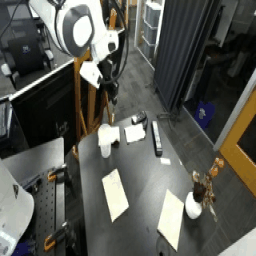

In [9]:
def as_gif(images, path="temp.gif"):
    # Renderizza le immagini come GIF
    # Usiamo una durata maggiore (es. 100ms) perché abbiamo solo 16 frame campionati
    images[0].save(path, save_all=True, append_images=images[1:], duration=100, loop=0)
    gif_bytes = open(path,"rb").read()
    return gif_bytes

# 1. Carica il file
file_path = "./data/droid/episode_6.pt" # o episode_1.pt
checkpoint = torch.load(file_path)
video = checkpoint['video']  # Shape: [16, 3, 256, 256]

# 2. Converti i Tensori in una lista di immagini PIL
pil_images = []
for i in range(video.shape[0]):
    # Permuta da [C, H, W] a [H, W, C] e converti in numpy uint8
    frame_np = video[i].permute(1, 2, 0).numpy()
    
    # Se i valori sono in range [0, 1] (float), riportali a [0, 255] (uint8)
    if frame_np.max() <= 1.0:
        frame_np = (frame_np * 255).astype(np.uint8)
    else:
        frame_np = frame_np.astype(np.uint8)
        
    pil_images.append(Image.fromarray(frame_np))

# 3. Genera e visualizza la GIF
print(f"Istruzione: {checkpoint['language'][0]}")
gif_data = as_gif(pil_images, path="preview_episode.gif")
display.Image(gif_data)